In [33]:
import numpy as np
import os
os.environ["KERAS_BACKEND"] = "torch"
import keras
import pandas as pd
import matplotlib.pyplot as plt
from keras import ops
def to_categorical(y, num_classes=None):
    y = ops.convert_to_tensor(y, dtype="int32")
    if num_classes is None:
        num_classes = int(ops.max(y)) + 1
    return ops.one_hot(y, num_classes)

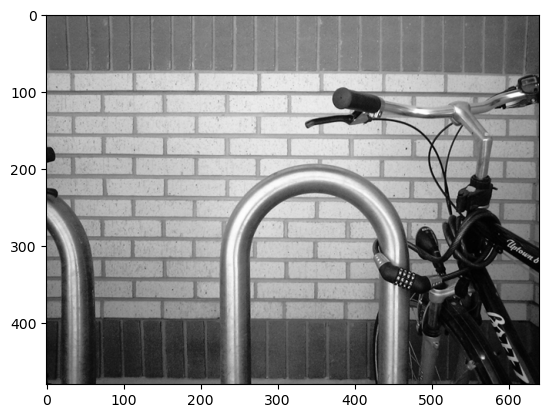

In [34]:
img = plt.imread("Bikesgray.png")
plt.imshow(img, cmap = "Greys_r")

In [35]:
img.shape

(480, 640)

In [36]:
def apply_filter(image, filter):
    h, w = image.shape
    fh, fv = filter.shape
    
    newimage = np.zeros((h - fh + 1, w - fv + 1))
    for i in range(h - fh + 1):
        for j in range(w - fv + 1):
            newimage[i, j] = np.sum(image[i:(i + fh), j:(j + fv)]*filter, axis = (0,1))
    return newimage

In [37]:
filter_size = 11
filterv = np.zeros((filter_size, filter_size))
filterh = np.zeros((filter_size, filter_size))
filterv[:, filter_size//2 + 1] = 1
filterh[filter_size//2 + 1, :] = 1

imgv = apply_filter(img , filterv)
imgh = apply_filter(img , filterh)


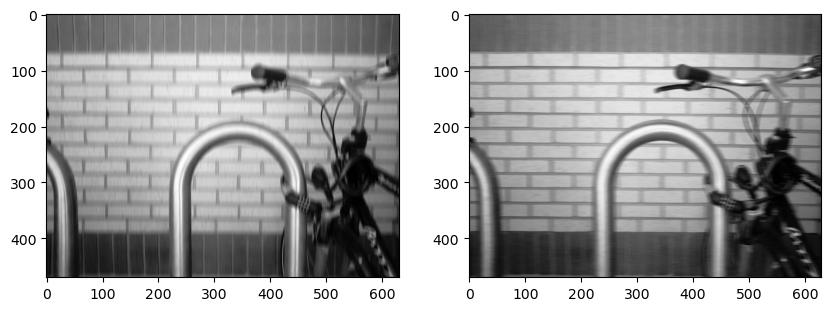

In [38]:
plt.figure(figsize = (10, 20))
plt.subplot(1, 2, 1)
plt.imshow(imgv, cmap = "Greys_r")
plt.subplot(1, 2, 2)
plt.imshow(imgh, cmap = "Greys_r")

In [39]:
filter_size = 31
filterv = np.zeros((filter_size, filter_size))
filterh = np.zeros((filter_size, filter_size))
filterv[:, filter_size//2 + 1] = 1
filterh[filter_size//2 + 1, :] = 1

imgv = apply_filter(img , filterv)
imgh = apply_filter(img , filterh)

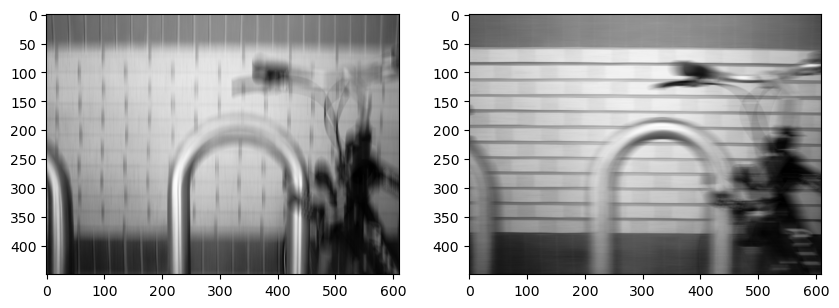

In [40]:
plt.figure(figsize = (10, 20))
plt.subplot(1, 2, 1)
plt.imshow(imgv, cmap = "Greys_r")
plt.subplot(1, 2, 2)
plt.imshow(imgh, cmap = "Greys_r")

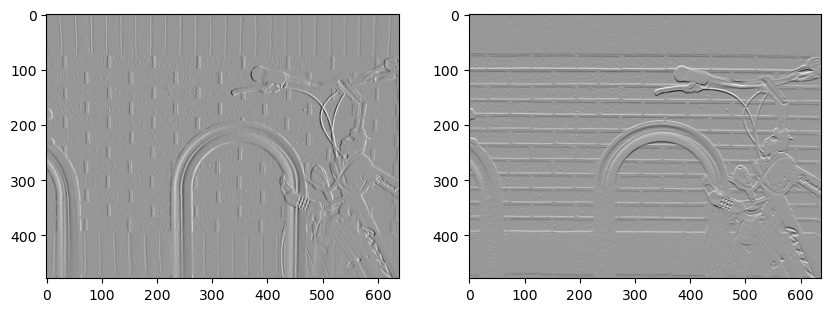

In [41]:
sobelv = np.array([[-1 , 0 ,1],[-2, 0 ,2],[-1, 0, 1]])
sobelh = np.array([[1 , 2 ,1],[0, 0 ,0],[-1, -2, -1]])

imgv = apply_filter(img , sobelv)
imgh = apply_filter(img , sobelh)

plt.figure(figsize = (10, 20))
plt.subplot(1, 2, 1)
plt.imshow(imgv, cmap = "Greys_r")
plt.subplot(1, 2, 2)
plt.imshow(imgh, cmap = "Greys_r")

In [42]:
trainData = pd.read_csv("mnist_train.zip")
testData = pd.read_csv("mnist_test.zip")
Xtrain, Ytrain = trainData.iloc[:,1:].to_numpy(), trainData.iloc[:, 0].to_numpy()
Xtest, Ytest = testData.iloc[:,1:].to_numpy(), testData.iloc[:, 0].to_numpy()
Xtrain , Xtest = Xtrain.reshape(-1 ,28 ,28), Xtest.reshape(-1, 28, 28)

In [43]:

Xtrain = Xtrain.astype("float32")/255
Xtest = Xtest.astype("float32")/255

In [44]:
Ytrain = to_categorical(Ytrain)
Ytest = to_categorical(Ytest)

In [45]:
Xtrain.shape

(59999, 28, 28)

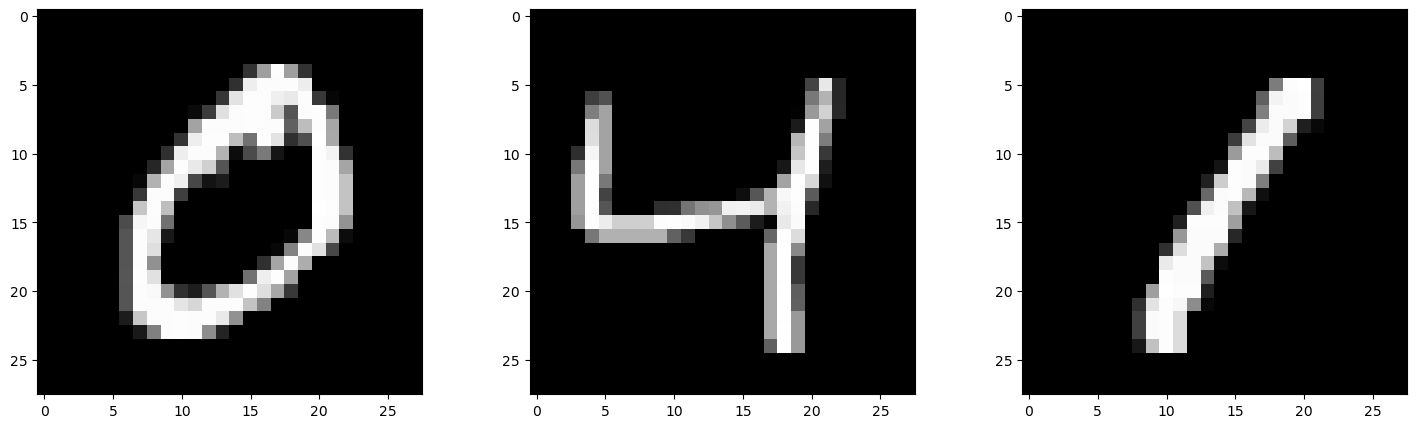

In [46]:
plt.figure(figsize = (18,5))
for i in range(3):
    plt.subplot(1, 3, i+1)
    plt.axis(True)
    plt.imshow(np.reshape(Xtrain[i], (28,28)), cmap = "gray")
    plt.subplots_adjust(wspace=0.2, hspace = 0.2)

In [47]:
num_filters = 8
filter_size = 3
pool_size = 2

model = keras.Sequential([
    keras.layers.Input(shape=(*Xtrain.shape[1:],1)),
    keras.layers.Conv2D(num_filters, filter_size),
    keras.layers.MaxPooling2D(pool_size=pool_size),
    keras.layers.Flatten(),
    keras.layers.Dense(10, activation='softmax')  
    
])

model.summary()

Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 13, 13, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_4 (Flatten)             │ (None, 1352)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 10)             │        13,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,610 (53.16 KB)

 Trainable params: 13,610 (53.16 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
model.compile(
    loss = keras.losses.CategoricalCrossentropy(),     
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),       
    metrics = [keras.metrics.CategoricalAccuracy(name = "accuracy")]
)

In [49]:
batch_size = 128
epochs = 20

trainState = model.fit(
    Xtrain,
    Ytrain,
    batch_size = batch_size,
    epochs = epochs,
    validation_split = 0.15
    
)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.7631 - loss: 0.8840 - val_accuracy: 0.9261 - val_loss: 0.2641
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9183 - loss: 0.2835 - val_accuracy: 0.9384 - val_loss: 0.2214
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9326 - loss: 0.2405 - val_accuracy: 0.9453 - val_loss: 0.1918
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9404 - loss: 0.2069 - val_accuracy: 0.9536 - val_loss: 0.1709
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9486 - loss: 0.1848 - val_accuracy: 0.9581 - val_loss: 0.1577
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9519 - loss: 0.1680 - val_accuracy: 0.9626 - val_loss: 0.1391
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9580 - loss: 0.1487 - val_accuracy: 0.9627 - val_loss: 0.1335
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9596 - loss: 0.1381 - val_accu

In [50]:
from matplotlib.ticker import (MultipleLocator,FormatStrFormatter)

def plot_results(metrics, title=None, ylabel=None, ylim=None, metric_name=None, color=None):
    
    fig, ax = plt.subplots(figsize=(15, 4))
    if not(isinstance(metric_name, list)or isinstance(metric_name, tuple)):
        metrics = [metrics,]
        metric_name = [metric_name,]
        
    for idx, metric in enumerate(metrics):
        ax.plot(metric, color=color[idx])
    
    plt.xlabel("Epoch")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.xlim([0, 20])
    plt.ylim(ylim)
    
    ax.xaxis.set_major_locator(MultipleLocator(5))
    ax.xaxis.set_major_formatter(FormatStrFormatter('%d'))
    ax.xaxis.set_major_locator(MultipleLocator(1))
    plt.grid("True")
    plt.show

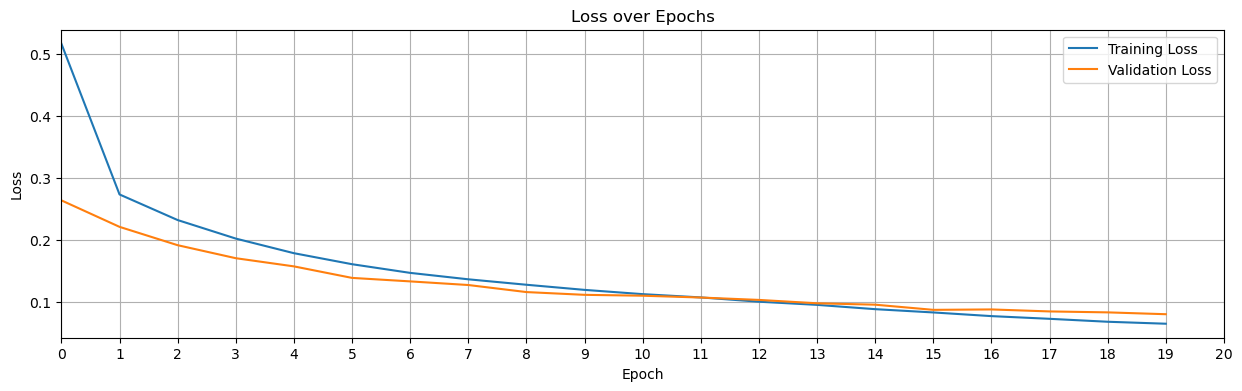

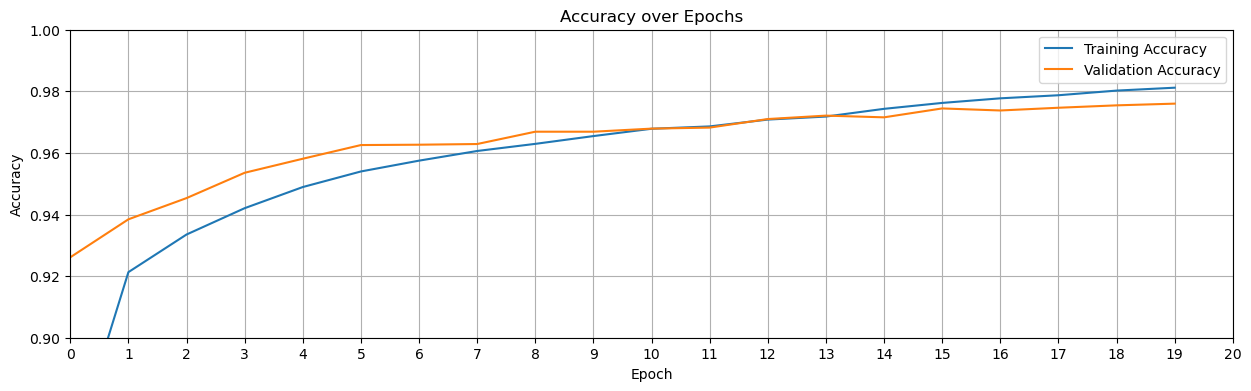

In [51]:
# Plot training vs validation loss
plot_results(
[trainState.history['loss'], trainState.history['val_loss']],
title='Loss over Epochs',
ylabel='Loss',
ylim=None,
metric_name=['loss', 'val_loss'],
color=['tab:blue', 'tab:orange']
)
plt.legend(['Training Loss', 'Validation Loss'])

# Plot training vs validation accuracy
plot_results(
[trainState.history['accuracy'], trainState.history['val_accuracy']],
title='Accuracy over Epochs',
ylabel='Accuracy',
ylim=[0.9,1],
metric_name=['accuracy', 'val_accuracy'],
color=['tab:blue', 'tab:orange']
)
plt.legend(['Training Accuracy', 'Validation Accuracy'])

In [52]:
w = model.layers[0].get_weights()[0]
w.shape

(3, 3, 1, 8)

In [53]:
w[ :, :, 0, 0]

array([[ 0.09744299,  0.5769744 ,  0.13955776],
       [ 0.2537178 ,  0.7508653 ,  0.6075782 ],
       [-1.2913505 , -0.5209888 , -0.15605664]], dtype=float32)

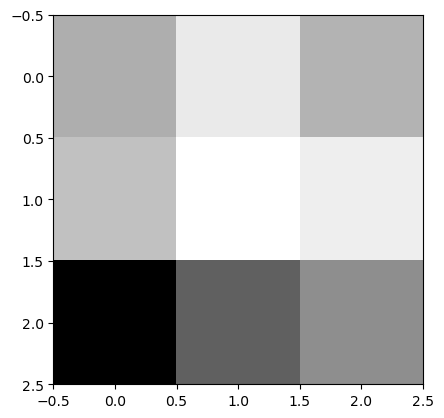

In [54]:
plt.imshow(w[:, :, 0, 0], cmap='gray')

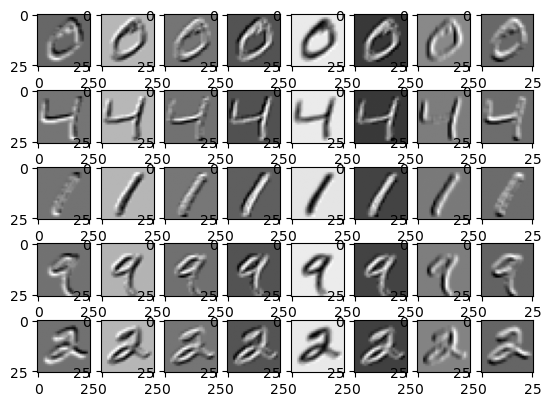

In [55]:
fig, ax = plt.subplots(5, 8)
for j in range(5):
    for i in range(8):
        ax[j, i].imshow(apply_filter(Xtrain[j, :, :], w[:, :, 0, i]), cmap="gray")

# Reducing Number of Filters

In [66]:
num_filters = 3
filter_size = 3
pool_size = 2

model = keras.Sequential([
    keras.layers.Input(shape=(*Xtrain.shape[1:],1)),
    keras.layers.Conv2D(num_filters, filter_size),
    keras.layers.MaxPooling2D(pool_size=pool_size),
    keras.layers.Flatten(),
    keras.layers.Dense(10, activation='softmax')  
    
])

model.summary()

model.compile(
    loss = keras.losses.CategoricalCrossentropy(),     
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),       
    metrics = [keras.metrics.CategoricalAccuracy(name = "accuracy")]
)

batch_size = 128
epochs = 20

trainState = model.fit(
    Xtrain,
    Ytrain,
    batch_size = batch_size,
    epochs = epochs,
    validation_split = 0.15
    
)

Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_10 (Conv2D)              │ (None, 26, 26, 3)      │            30 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_10 (MaxPooling2D) │ (None, 13, 13, 3)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_10 (Flatten)            │ (None, 507)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_10 (Dense)                │ (None, 10)             │         5,080 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,110 (19.96 KB)

 Trainable params: 5,110 (19.96 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.6489 - loss: 1.2888 - val_accuracy: 0.9141 - val_loss: 0.3034
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9057 - loss: 0.3249 - val_accuracy: 0.9308 - val_loss: 0.2476
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9227 - loss: 0.2666 - val_accuracy: 0.9384 - val_loss: 0.2217
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9311 - loss: 0.2419 - val_accuracy: 0.9449 - val_loss: 0.2039
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9370 - loss: 0.2220 - val_accuracy: 0.9493 - val_loss: 0.1891
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9412 - loss: 0.2091 - val_accuracy: 0.9508 - val_loss: 0.1786
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 19ms/step - accuracy: 0.9457 - loss: 0.1907 - val_accuracy: 0.9533 - val_loss: 0.1694
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 18ms/step - accuracy: 0.9499 - loss: 0.1728 - val_accu

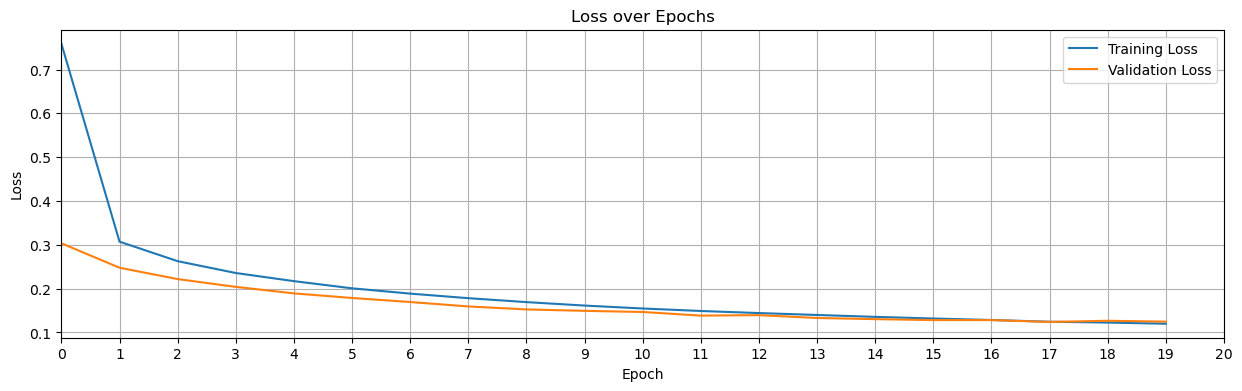

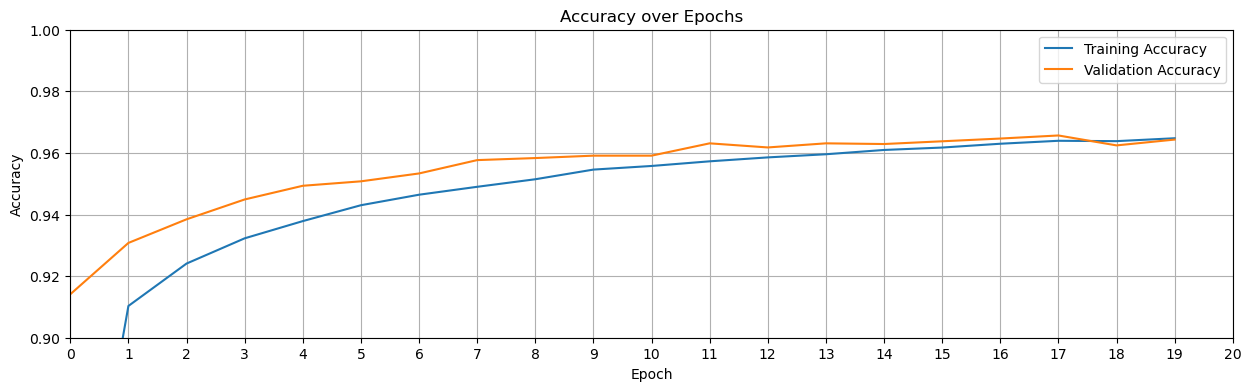

In [67]:
# Plot training vs validation loss
plot_results(
[trainState.history['loss'], trainState.history['val_loss']],
title='Loss over Epochs',
ylabel='Loss',
ylim=None,
metric_name=['loss', 'val_loss'],
color=['tab:blue', 'tab:orange']
)
plt.legend(['Training Loss', 'Validation Loss'])

# Plot training vs validation accuracy
plot_results(
[trainState.history['accuracy'], trainState.history['val_accuracy']],
title='Accuracy over Epochs',
ylabel='Accuracy',
ylim=[0.9,1],
metric_name=['accuracy', 'val_accuracy'],
color=['tab:blue', 'tab:orange']
)
plt.legend(['Training Accuracy', 'Validation Accuracy'])

As you can see by reducing the number of filters, the model loss is higher than 0.1 however in our initial model loss reached lower than 0.1

# Increasing Filter Size

In [58]:
num_filters = 8
filter_size = 5
pool_size = 2

model = keras.Sequential([
    keras.layers.Input(shape=(*Xtrain.shape[1:],1)),
    keras.layers.Conv2D(num_filters, filter_size),
    keras.layers.MaxPooling2D(pool_size=pool_size),
    keras.layers.Flatten(),
    keras.layers.Dense(10, activation='softmax')  
    
])

model.summary()

model.compile(
    loss = keras.losses.CategoricalCrossentropy(),     
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),       
    metrics = [keras.metrics.CategoricalAccuracy(name = "accuracy")]
)

batch_size = 128
epochs = 20

trainState = model.fit(
    Xtrain,
    Ytrain,
    batch_size = batch_size,
    epochs = epochs,
    validation_split = 0.15
    
)

Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_6 (Conv2D)               │ (None, 24, 24, 8)      │           208 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 12, 12, 8)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_6 (Flatten)             │ (None, 1152)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 10)             │        11,530 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 11,738 (45.85 KB)

 Trainable params: 11,738 (45.85 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.7537 - loss: 0.8831 - val_accuracy: 0.9353 - val_loss: 0.2319
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9293 - loss: 0.2425 - val_accuracy: 0.9544 - val_loss: 0.1696
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9496 - loss: 0.1775 - val_accuracy: 0.9644 - val_loss: 0.1312
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9613 - loss: 0.1370 - val_accuracy: 0.9702 - val_loss: 0.1105
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9682 - loss: 0.1140 - val_accuracy: 0.9718 - val_loss: 0.1018
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9734 - loss: 0.0962 - val_accuracy: 0.9756 - val_loss: 0.0916
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9763 - loss: 0.0842 - val_accuracy: 0.9766 - val_loss: 0.0853
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9777 - loss: 0.0778 - val_accu

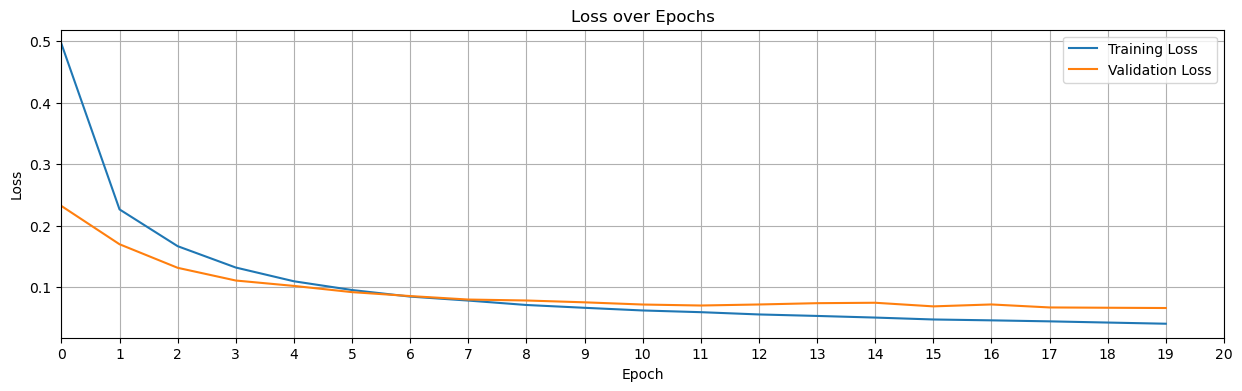

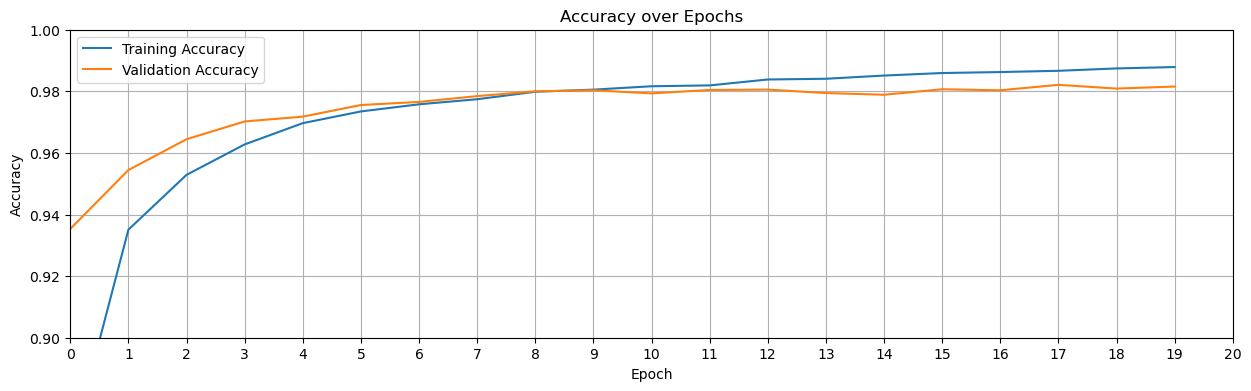

In [59]:
# Plot training vs validation loss
plot_results(
[trainState.history['loss'], trainState.history['val_loss']],
title='Loss over Epochs',
ylabel='Loss',
ylim=None,
metric_name=['loss', 'val_loss'],
color=['tab:blue', 'tab:orange']
)
plt.legend(['Training Loss', 'Validation Loss'])

# Plot training vs validation accuracy
plot_results(
[trainState.history['accuracy'], trainState.history['val_accuracy']],
title='Accuracy over Epochs',
ylabel='Accuracy',
ylim=[0.9,1],
metric_name=['accuracy', 'val_accuracy'],
color=['tab:blue', 'tab:orange']
)
plt.legend(['Training Accuracy', 'Validation Accuracy'])


As you can see by increasing the size of filters, the model loss reaches lower than 0.1 

# increasing Pool Size

In [60]:
num_filters = 8
filter_size = 3
pool_size = 4

model = keras.Sequential([
    keras.layers.Input(shape=(*Xtrain.shape[1:],1)),
    keras.layers.Conv2D(num_filters, filter_size),
    keras.layers.MaxPooling2D(pool_size=pool_size),
    keras.layers.Flatten(),
    keras.layers.Dense(10, activation='softmax')  
    
])

model.summary()

model.compile(
    loss = keras.losses.CategoricalCrossentropy(),     
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),       
    metrics = [keras.metrics.CategoricalAccuracy(name = "accuracy")]
)

batch_size = 128
epochs = 20

trainState = model.fit(
    Xtrain,
    Ytrain,
    batch_size = batch_size,
    epochs = epochs,
    validation_split = 0.15
    
)

Model: "sequential_7"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_7 (Conv2D)               │ (None, 26, 26, 8)      │            80 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 6, 6, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_7 (Flatten)             │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 10)             │         2,890 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,970 (11.60 KB)

 Trainable params: 2,970 (11.60 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.5984 - loss: 1.4053 - val_accuracy: 0.9027 - val_loss: 0.3398
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9023 - loss: 0.3450 - val_accuracy: 0.9366 - val_loss: 0.2307
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9274 - loss: 0.2510 - val_accuracy: 0.9490 - val_loss: 0.1867
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9400 - loss: 0.2057 - val_accuracy: 0.9551 - val_loss: 0.1628
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 5s 14ms/step - accuracy: 0.9483 - loss: 0.1772 - val_accuracy: 0.9594 - val_loss: 0.1461
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9534 - loss: 0.1549 - val_accuracy: 0.9630 - val_loss: 0.1323
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9575 - loss: 0.1441 - val_accuracy: 0.9656 - val_loss: 0.1240
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9597 - loss: 0.1318 - val_accu

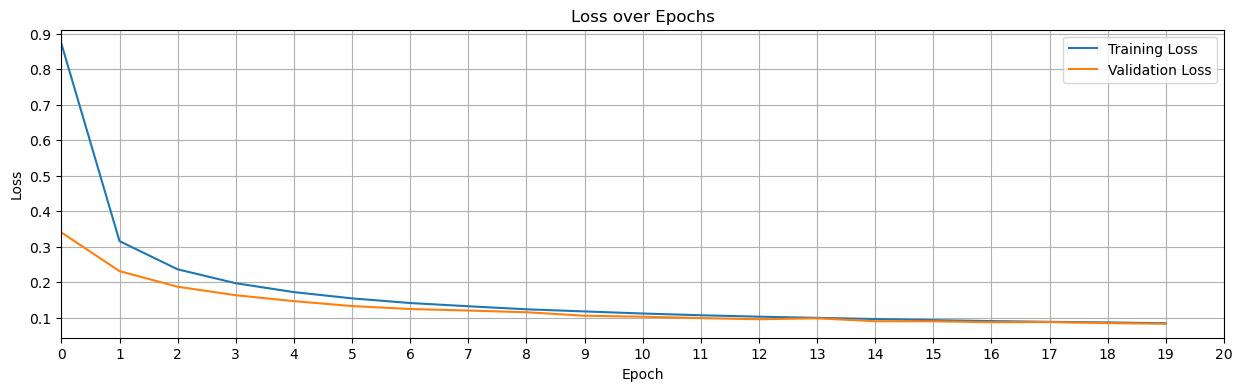

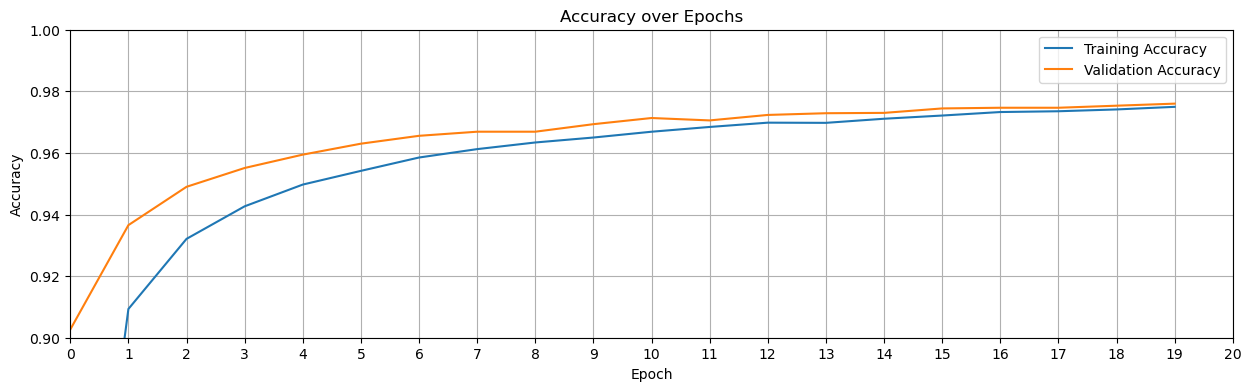

In [61]:
# Plot training vs validation loss
plot_results(
[trainState.history['loss'], trainState.history['val_loss']],
title='Loss over Epochs',
ylabel='Loss',
ylim=None,
metric_name=['loss', 'val_loss'],
color=['tab:blue', 'tab:orange']
)
plt.legend(['Training Loss', 'Validation Loss'])

# Plot training vs validation accuracy
plot_results(
[trainState.history['accuracy'], trainState.history['val_accuracy']],
title='Accuracy over Epochs',
ylabel='Accuracy',
ylim=[0.9,1],
metric_name=['accuracy', 'val_accuracy'],
color=['tab:blue', 'tab:orange']
)
plt.legend(['Training Accuracy', 'Validation Accuracy'])

As you can see by increasing the number of pool size, the model loss is lower than 0.1 however it is really close to 0.1

# new model

In [68]:
num_filters = 16
filter_size = 6
pool_size = 2

model = keras.Sequential([
    keras.layers.Input(shape=(*Xtrain.shape[1:],1)),
    keras.layers.Conv2D(num_filters, filter_size),
    keras.layers.MaxPooling2D(pool_size=pool_size),
    keras.layers.Flatten(),
    keras.layers.Dense(10, activation='softmax')  
    
])

model.summary()

model.compile(
    loss = keras.losses.CategoricalCrossentropy(),     
    optimizer = keras.optimizers.Adam(learning_rate = 0.001),       
    metrics = [keras.metrics.CategoricalAccuracy(name = "accuracy")]
)

batch_size = 128
epochs = 20

trainState = model.fit(
    Xtrain,
    Ytrain,
    batch_size = batch_size,
    epochs = epochs,
    validation_split = 0.15
    
)

Model: "sequential_11"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_11 (Conv2D)              │ (None, 23, 23, 16)     │           592 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_11 (MaxPooling2D) │ (None, 11, 11, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_11 (Flatten)            │ (None, 1936)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_11 (Dense)                │ (None, 10)             │        19,370 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 19,962 (77.98 KB)

 Trainable params: 19,962 (77.98 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.7925 - loss: 0.7459 - val_accuracy: 0.9409 - val_loss: 0.2156
Epoch 2/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 15ms/step - accuracy: 0.9391 - loss: 0.2180 - val_accuracy: 0.9624 - val_loss: 0.1499
Epoch 3/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 8s 21ms/step - accuracy: 0.9587 - loss: 0.1485 - val_accuracy: 0.9697 - val_loss: 0.1155
Epoch 4/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 9s 22ms/step - accuracy: 0.9699 - loss: 0.1100 - val_accuracy: 0.9761 - val_loss: 0.0922
Epoch 5/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.9748 - loss: 0.0894 - val_accuracy: 0.9798 - val_loss: 0.0790
Epoch 6/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 17ms/step - accuracy: 0.9785 - loss: 0.0778 - val_accuracy: 0.9806 - val_loss: 0.0758
Epoch 7/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 6s 16ms/step - accuracy: 0.9803 - loss: 0.0667 - val_accuracy: 0.9813 - val_loss: 0.0709
Epoch 8/20
399/399 ━━━━━━━━━━━━━━━━━━━━ 7s 16ms/step - accuracy: 0.9820 - loss: 0.0637 - val_accu

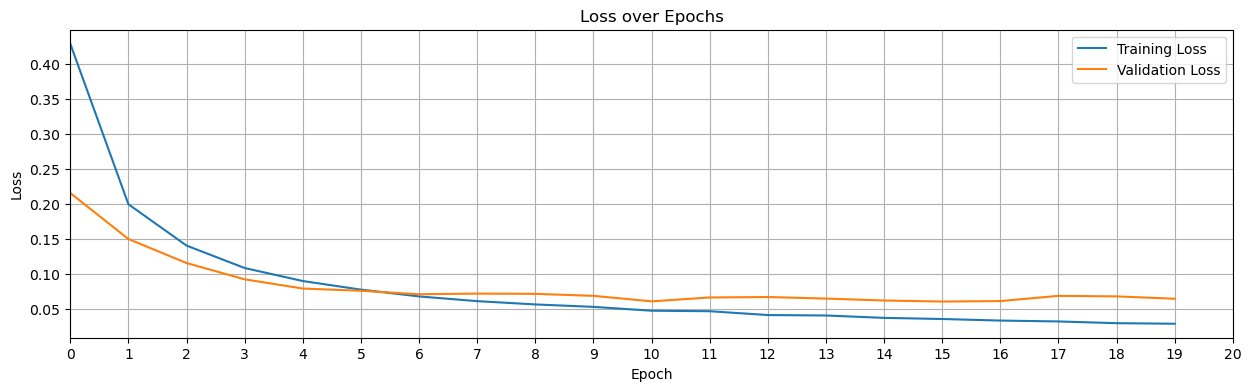

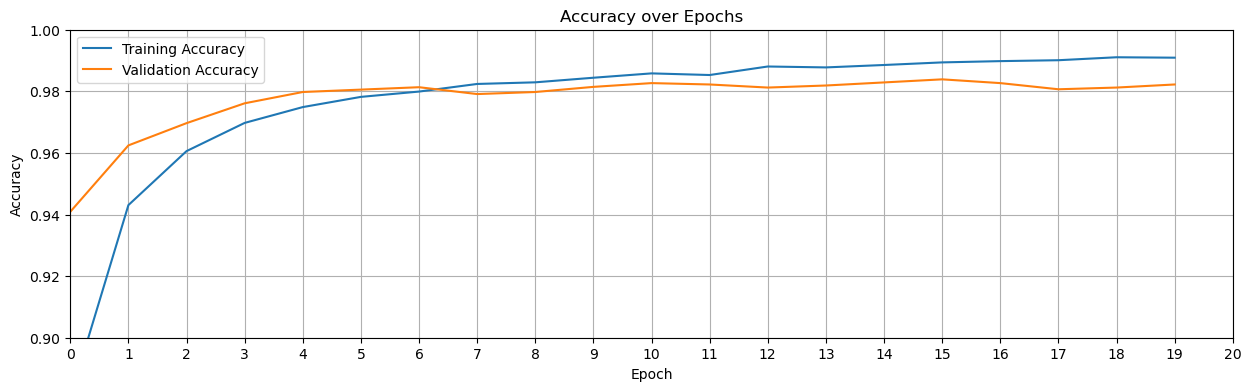

In [69]:
# Plot training vs validation loss
plot_results(
[trainState.history['loss'], trainState.history['val_loss']],
title='Loss over Epochs',
ylabel='Loss',
ylim=None,
metric_name=['loss', 'val_loss'],
color=['tab:blue', 'tab:orange']
)
plt.legend(['Training Loss', 'Validation Loss'])

# Plot training vs validation accuracy
plot_results(
[trainState.history['accuracy'], trainState.history['val_accuracy']],
title='Accuracy over Epochs',
ylabel='Accuracy',
ylim=[0.9,1],
metric_name=['accuracy', 'val_accuracy'],
color=['tab:blue', 'tab:orange']
)
plt.legend(['Training Accuracy', 'Validation Accuracy'])

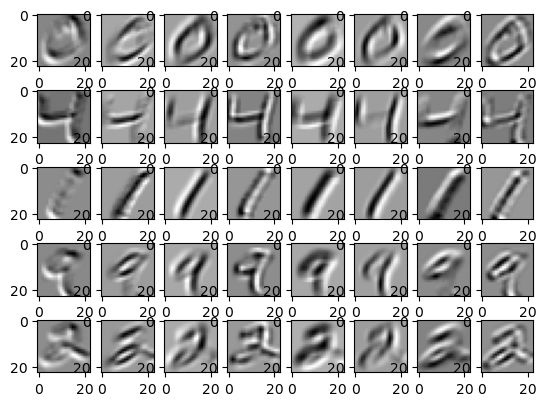

In [71]:
w = model.layers[0].get_weights()[0]

fig, ax = plt.subplots(5, 8)
for j in range(5):
    for i in range(8):
        ax[j, i].imshow(apply_filter(Xtrain[j, :, :], w[:, :, 0, i]), cmap="gray")